In [1]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np

from astropy.table import Table
import sys, os, tqdm, glob
wdmodels_dir = os.environ['WDMODELS_DIR']
sys.path.append(wdmodels_dir)
import WD_models

plt.style.use("stefan.mplstyle")
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage[T1]{fontenc}\usepackage{lmodern}\usepackage{amsmath}",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

In [2]:
LOGG_SUN = 4.437

data = pd.read_parquet("../widebinaries/data/merges/ngf21_merged.pqt")
data.rename({"E(BP/RP)":"bp_rp_excess"}, axis=1, inplace=True)
data = data.query("RUWE < 1.2 & bp_rp_excess < 1.2")
data["RadiusH"] = np.sqrt(data.MassH * 10**(LOGG_SUN - data.loggH))
data["Radiusmix"] = np.sqrt(data.Massmix * 10**(LOGG_SUN - data.loggmix))
data["RadiusHe"] = np.sqrt(data.MassHe * 10**(LOGG_SUN - data.loggHe))

In [3]:
list(data.keys())

['sourceid',
 'radius_thick',
 'teff_thick',
 'dist_thick',
 'av_thick',
 'std_rr_thick',
 'std_tt_thick',
 'std_dist_thick',
 'std_av_thick',
 'cov_rt_thick',
 'nsamps_thick',
 'radius_thin',
 'teff_thin',
 'dist_thin',
 'av_thin',
 'std_rr_thin',
 'std_tt_thin',
 'std_dist_thin',
 'std_av_thin',
 'cov_rt_thin',
 'nsamps_thin',
 'radius_mixed',
 'teff_mixed',
 'dist_mixed',
 'av_mixed',
 'std_rr_mixed',
 'std_tt_mixed',
 'std_dist_mixed',
 'std_av_mixed',
 'cov_rt_mixed',
 'nsamps_mixed',
 'PDA',
 'PDB',
 'PDC',
 'PDO',
 'PDQ',
 'PDZ',
 'teff_best',
 'std_tt_best',
 'radius_best',
 'std_rr_best',
 'cov_rt_best',
 'av_best',
 'std_av_best',
 'dist_best',
 'std_dist_best',
 'nsamps_best',
 'mass_best',
 'log_age_cool',
 'log_age',
 'log_age_cool_hi',
 'log_age_hi',
 'log_age_cool_lo',
 'log_age_lo',
 'recno',
 'WDJname',
 'GaiaEDR3',
 'GaiaDR2',
 'EDR3Name',
 'RA_ICRS',
 'e_RA_ICRS',
 'DE_ICRS',
 'e_DE_ICRS',
 'Plx',
 'e_Plx',
 'RPlx',
 'ZPcor',
 'Pwd',
 'density',
 'SolID',
 'RandomI',

In [4]:
def mass_from_loggteff(loggarray : np.array, teffarray : np.array, 
                       low_model = 'be', mid_model = 'be', high_model = 'be',
                       atm_type = 'H') -> np.array:
    """compute the radial velocity from radius and effective temperature
    """
    mass_sun, radius_sun, newton_G, speed_light = 1.9884e30, 6.957e8, 6.674e-11, 299792458
    font_model = WD_models.load_model(low_model, mid_model, high_model, atm_type) 
    g_acc = (10**font_model['logg'])/100
    rsun = np.sqrt(font_model['mass_array'] * mass_sun * newton_G / g_acc) / radius_sun
    rad_teff_to_mass = WD_models.interp_xy_z_func(x = rsun, y = 10**font_model['logteff'],\
                                                z = font_model['mass_array'], interp_type = 'linear')
    return rad_teff_to_mass(loggarray, teffarray)

function = np.where(data["PDA"] > 0.5, "H", "He")
mH = function == "H"
mHe = function == "He"

len(data)

7264

In [5]:
def covariance_ellipse(x, y, n_std=1.0, center=None, **kwargs):
    """Return a matplotlib Ellipse representing the n_std covariance ellipse"""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]

    cov = np.cov(x, y)
    vals, vecs = np.linalg.eigh(cov)

    # sort eigenvalues/vectors
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]

    # ellipse parameters
    width, height = 2 * n_std * np.sqrt(vals)
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

    if center is None:
        center = (np.mean(x), np.mean(y))

    return patches.Ellipse(
        xy=center,
        width=width,
        height=height,
        angle=angle,
        fill=False,
        **kwargs
    )

def plot_dataset(xx, yy, ax, xlims, ylims, 
                 xlabel="$\\Delta R$ [\\%]",
                 ylabel="$\\Delta T_\\text{eff}$ [\\%]"):
    c = ax.hexbin(xx, yy, bins="log", cmap="managua", gridsize=150, vmin=1, vmax=1e2)

    confidence_ellipses = [3, 5, 10]
    for val in confidence_ellipses:
        circle = patches.Circle((0, 0), val, edgecolor='blue', facecolor='none', ls = '-', linewidth=2, label='')
        ax.add_patch(circle)

    ax.text(
        0.05, 0.25,
        rf"$\langle \Delta T_\mathrm{{eff}} \rangle = "
        rf"{np.mean(yy):1.2f}\%$"
        "\n\n"
        rf"$\langle \Delta R \rangle = "
        rf"{np.mean(xx):1.2f}\%$",
        color="k",
        ha="left",
        va="top",
        fontsize=16,
        transform=ax.transAxes
    )

    # In-panel colorbar
    cax = ax.inset_axes([0.5, 0.87, 0.4, 0.05])  # [x, y, width, height] in axes coords
    cbar = ax.get_figure().colorbar(c, cax=cax, orientation="horizontal")
    cbar.set_label("Count", fontsize=16, labelpad=2)
    cbar.ax.tick_params(labelsize=14)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.set_xlim(xlims[0], xlims[1])
    ax.set_ylim(ylims[0], ylims[1])


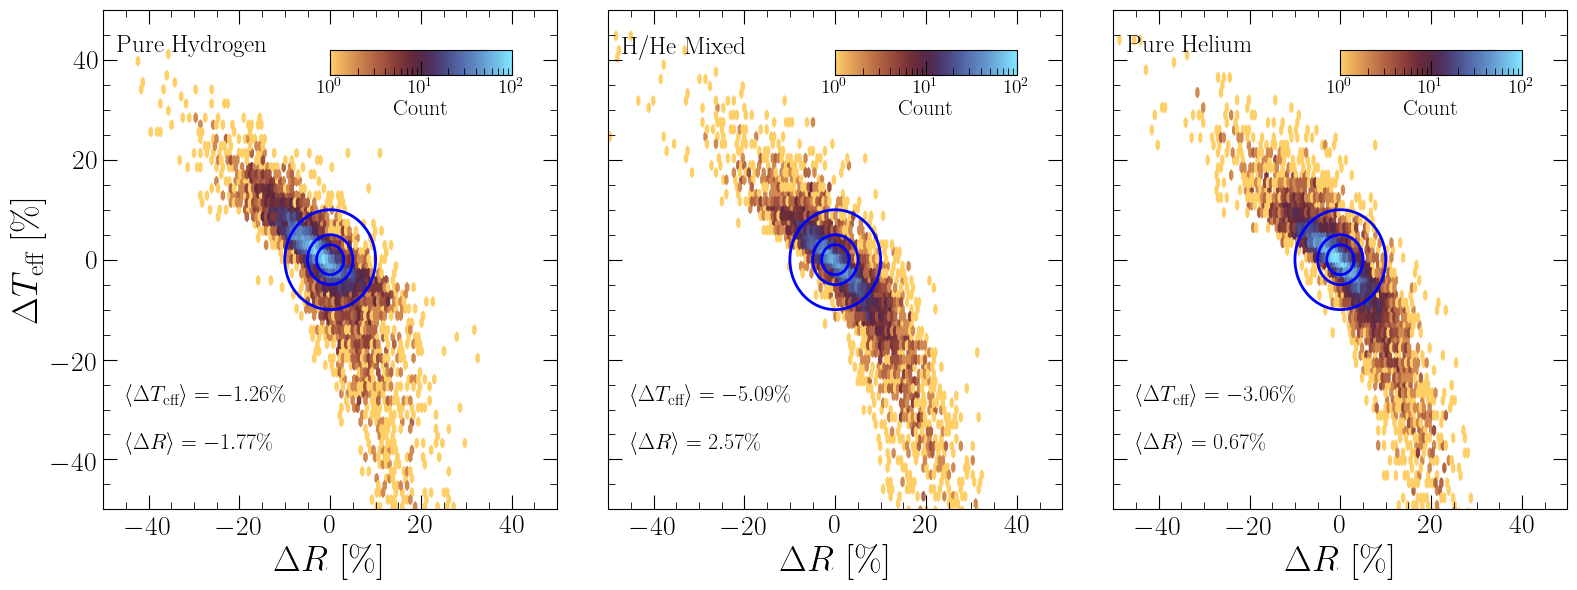

In [6]:
fig, ax = plt.subplots(ncols=3, figsize=(16,6), sharey=True)

mask = data.mass_best > 0.45

teff_pct_err_thick = 100*(data.teff_thick - data.TeffH) / data.teff_thick
logg_pct_err_thick = 100*(data.radius_thick - data.RadiusH) / data.radius_thick
plot_dataset(logg_pct_err_thick[mask], teff_pct_err_thick[mask], ax[0], (-50, 50), (-50, 50),)
ax[0].text(
    0.03, 0.95, rf"Pure Hydrogen",
    ha="left", va="top",
    fontsize=18, transform=ax[0].transAxes
)

teff_pct_err_mixed = 100*(data.teff_mixed - data.Teffmix) / data.teff_mixed
logg_pct_err_mixed = 100*(data.radius_mixed - data.Radiusmix) / data.radius_mixed
plot_dataset(logg_pct_err_mixed[mask], teff_pct_err_mixed[mask], ax[1], (-50, 50), (-50, 50),
             ylabel="")
ax[1].text(
    0.03, 0.95, rf"H/He Mixed",
    ha="left", va="top",
    fontsize=18, transform=ax[1].transAxes
)

teff_pct_err_thin = 100*(data.teff_thin - data.TeffHe) / data.teff_thin
logg_pct_err_thin = 100*(data.radius_thin - data.RadiusHe) / data.radius_thin
plot_dataset(logg_pct_err_thin[mask], teff_pct_err_thin[mask], ax[2], (-50, 50), (-50, 50),
             ylabel="")
ax[2].text(
    0.03, 0.95, rf"Pure Helium",
    ha="left", va="top",
    fontsize=18, transform=ax[2].transAxes
)

fig.tight_layout()
fig.savefig("figures/comparison_ngf21.pdf")

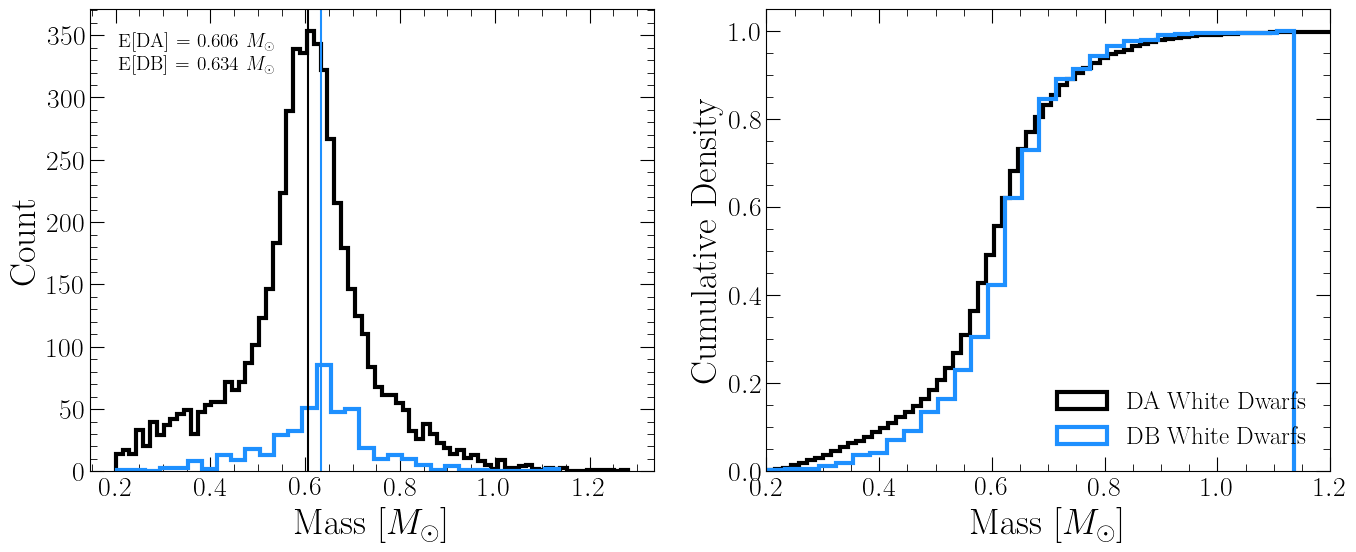

In [7]:
data_da = data.query("PDA > 0.8")
data_db = data.query("PDB > 0.8")

fig, ax = plt.subplots(ncols=2, figsize=(16, 6))

ax[0].hist(data_da.mass_best, histtype="step", linewidth=3, color="k", label="DA White Dwarfs");
ax[0].hist(data_db.mass_best, histtype="step", linewidth=3, color="dodgerblue", label="DB White Dwarfs");

mu_da = np.nanmedian(data_da.mass_best)
mu_db = np.nanmedian(data_db.mass_best) 

ax[0].axvline(mu_da, c='k')
ax[0].axvline(mu_db, c='dodgerblue')

ax[0].text(
    0.05, 0.95,
    fr"E[DA] = {mu_da:.3f} $M_\odot$" "\n" fr"E[DB] = {mu_db:.3f} $M_\odot$",
    transform=ax[0].transAxes,
    va="top",
    ha="left",
    fontsize=14,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.8)   
)

ax[0].set_xlabel("Mass [$M_\\odot$]")
ax[0].set_ylabel("Count")

ax[1].hist(data_da.mass_best, histtype="step", linewidth=3, color="k", label="DA White Dwarfs",  cumulative=True, density=True);
ax[1].hist(data_db.mass_best, histtype="step", linewidth=3, color="dodgerblue", label="DB White Dwarfs",  cumulative=True, density=True);
ax[1].set_xlim(0.2, 1.2)
ax[1].set_xlabel("Mass [$M_\\odot$]")
ax[1].set_ylabel("Cumulative Density")
ax[1].legend(framealpha=0)


In [8]:
crys = pd.read_csv("../widebinaries/data/crystallization.csv")

model = WD_models.load_model(low_mass_model='Bedard2020',
                             middle_mass_model='Bedard2020',
                             high_mass_model='Bedard2020',
                             atm_type='H',
                             HR_bands=('bp3-rp3', 'G3'))

logg_20pct = model["HR_to_logg"](crys["bprp_20pct"].to_numpy(), crys["gabs_20pct"].to_numpy())
mass_20pct = model["HR_to_mass"](crys["bprp_20pct"].to_numpy(), crys["gabs_20pct"].to_numpy())
radius_20pct = np.sqrt(mass_20pct * 10**(LOGG_SUN - logg_20pct))
teff_20pct = 10**model["HR_to_logteff"](crys["bprp_20pct"].to_numpy(), crys["gabs_20pct"].to_numpy())

logg_80pct = model["HR_to_logg"](crys["bprp_80pct"].to_numpy(), crys["gabs_80pct"].to_numpy())
mass_80pct = model["HR_to_mass"](crys["bprp_80pct"].to_numpy(), crys["gabs_80pct"].to_numpy())
radius_80pct = np.sqrt(mass_80pct * 10**(LOGG_SUN - logg_80pct))
teff_80pct = 10**model["HR_to_logteff"](crys["bprp_80pct"].to_numpy(), crys["gabs_80pct"].to_numpy())



In [9]:
def radius_from_massteff(massarray : np.array, teffarray : np.array, 
                       low_model = 'be', mid_model = 'be', high_model = 'be',
                       atm_type = 'H') -> np.array:
    """compute the radial velocity from radius and effective temperature
    """
    mass_sun, radius_sun, newton_G, speed_light = 1.9884e30, 6.957e8, 6.674e-11, 299792458
    font_model = WD_models.load_model(low_model, mid_model, high_model, atm_type) 
    g_acc = (10**font_model['logg'])/100
    rsun = np.sqrt(font_model['mass_array'] * mass_sun * newton_G / g_acc) / radius_sun
    mass_teff_to_radius = WD_models.interp_xy_z_func(x = font_model['mass_array'], y = 10**font_model['logteff'],\
                                                z = rsun, interp_type = 'linear')
    return mass_teff_to_radius(massarray, teffarray)

teffs = np.linspace(4000, 50000, 100)
radii = radius_from_massteff(0.6, teffs)*109.75

0.6137646586310191
0.5193
0.01274372839939845 4.507577651471366e-05
537


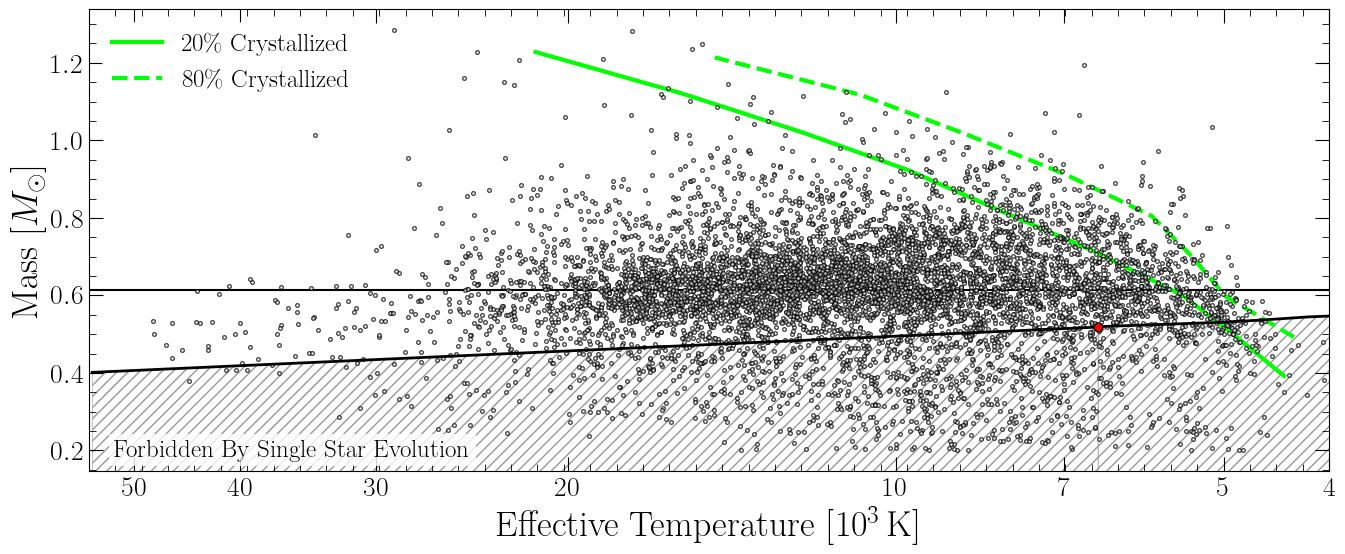

In [10]:
fig, ax = plt.subplots(figsize=(16, 6))

ifmr = pd.read_csv("../widebinaries/data/MESA_IFMR/ifmr_data.csv")

ax.scatter(np.log10(data.teff_best), 
           data.mass_best, 
           c='white', edgecolor="k", 
           alpha=0.7, s=7,  zorder=5,
           rasterized=True)
#ax.hexbin(np.log10(data.teff_best + np.random.uniform(0, data.e_teff_best, size=len(data))), 
#           data.logg_best + np.random.uniform(0, data.e_logg_best, size=len(data)), 
#           bins="log", gridsize=150, cmap="cividis")
#ax.plot(np.log10(teffs), radii, c="k")
ax.axhline(np.nanmedian(data.mass_best), c="k")
ax.plot(np.log10(teff_20pct), mass_20pct, c="lime", lw=3, label="20\\% Crystallized")
ax.plot(np.log10(teff_80pct), mass_80pct, c="lime", ls="--", lw=3, label="80\\% Crystallized")
print(np.nanmedian(data.mass_best))

ylims = ax.get_ylim()

mask = ifmr.teff_max > 4000
z = np.polyfit(np.log10(ifmr.loc[mask, "teff_max"]), ifmr.loc[mask, "M_final"], 1)
p = np.poly1d(z)

min_t = ax.get_xlim()[1]
max_t = max(np.log10(ifmr.teff_max))
t_fit = np.linspace(min_t, max_t, 3)
M_extrap = p(t_fit)
tarr = np.concatenate((t_fit, np.log10(ifmr.teff_max)))
Marr = np.concatenate((M_extrap, ifmr.M_final))

# Hatched region below the IFMR
ax.fill_between(
    np.log10(ifmr.teff_max), ifmr.M_final,
    ylims[0],                               # fill down to the plot floor
    hatch="///", facecolor="none",
    edgecolor="0.6", linewidth=0.4, zorder=1,
)
ax.fill_between(
    t_fit, p(t_fit),
    ylims[0],
    hatch="///", facecolor="none",
    edgecolor="0.6", linewidth=0.4, zorder=1,
)

# Clean fit line
ax.plot(t_fit, p(t_fit), c="k", lw=2, zorder=7)
ax.plot(np.log10(ifmr.teff_max), ifmr.M_final, c="k", lw=2, zorder=7)
ax.scatter([max_t], min(ifmr.M_final), s=40, c="red", edgecolor="k", zorder=100)
ax.text(0.02, 0.07, "Forbidden By Single Star Evolution",
        ha='left', va='top', fontsize=18, transform=ax.transAxes,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8))
ax.set_ylim(ylims)
print(min(ifmr.M_final))

ax.invert_xaxis()
leg = ax.legend(frameon=True,
    facecolor="white",
    framealpha=0.8
)
leg.get_frame().set_edgecolor("none")

print(data.radius_best.median(), data.radius_best.std() / np.sqrt(len(data)))
#ax.axhline(data.logg_best.median(), c="k", lw=2, ls=":")

ticks_kK = np.array([50, 40, 30, 20, 10, 7, 5, 4])   # in 10^3 K
tick_locs = np.log10(ticks_kK * 1e3)
ax.set_xticks(tick_locs)
ax.set_xticklabels([f"{t:g}" for t in ticks_kK])
ax.set_xlabel(r"Effective Temperature $[10^3\,\mathrm{K}]$")
ax.set_ylabel(r"Mass [$M_\odot$]")

ax.set_xlim(np.log10(55000), np.log10(4000))

print(len(data[data.teff_best < 6000]))
data = data.query("teff_best > 6000")

fig.savefig("figures/kieldiagram.pdf")

In [11]:
from wdwarfdate.wdwarfdate import WhiteDwarf

data_ages = pd.read_parquet("../widebinaries/data/merges/wbinary_gyro_ages_lu.pqt").reset_index().query("teff_best > 6000")

function = np.where(data_ages["PDA"] > 0.5, "H", "He")
mH = function == "H"
mHe = function == "He"

data_ages["wd_age"] = 10**(data_ages["log_age"] - 9)
data_ages["wd_age_lo"] = 10**(data_ages["log_age_lo"] - 9)
data_ages["wd_age_hi"] = 10**(data_ages["log_age_hi"] - 9)

data_ages["wd_cool_age"] = 10**(data_ages["log_age_cool"] - 9)
data_ages["wd_cool_age_lo"] = 10**(data_ages["log_age_cool_lo"] - 9)
data_ages["wd_cool_age_hi"] = 10**(data_ages["log_age_cool_hi"] - 9)

In [12]:
len(data.query("mass_best > 0.63"))

2969

In [13]:
mask = (data_ages["mass_best"] > 0.63)

### real datapoints
x = data_ages.loc[mask, "wd_age"].to_numpy()
xlo = x - data_ages.loc[mask, "wd_age_lo"].to_numpy()
xhi = data_ages.loc[mask, "wd_age_hi"].to_numpy() - x

y = data_ages.loc[mask, "Age"].to_numpy()
ylo = np.abs(data_ages.loc[mask, "e_Age"].to_numpy())
yhi = data_ages.loc[mask, "E_Age"].to_numpy()

### lower bounds
x_cool = data_ages.loc[~mask, "wd_cool_age"].to_numpy()
xlo_cool = x_cool - data_ages.loc[~mask, "wd_cool_age_lo"].to_numpy()
xhi_cool = data_ages.loc[~mask, "wd_cool_age_hi"].to_numpy() - x_cool

y_cool = data_ages.loc[~mask, "Age"].to_numpy()
ylo_cool = np.abs(data_ages.loc[~mask, "e_Age"].to_numpy())
yhi_cool = data_ages.loc[~mask, "E_Age"].to_numpy()

In [14]:
len(x), len(x_cool), len(x) + len(x_cool)

(45, 46, 91)

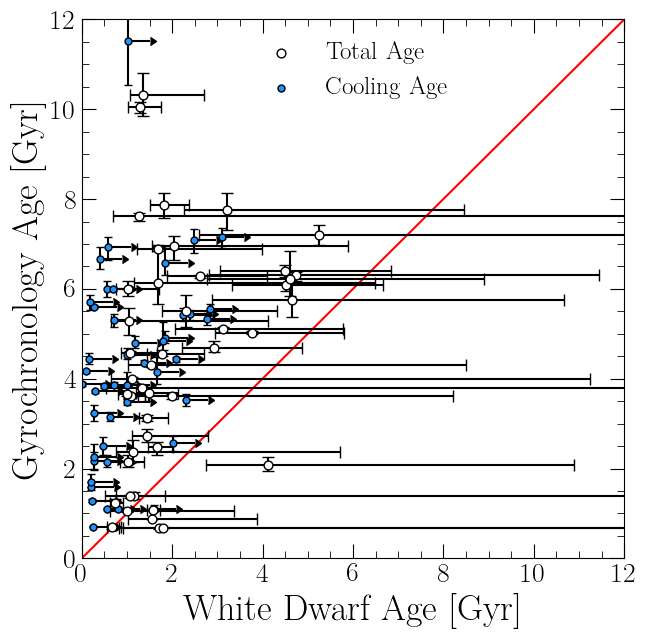

In [15]:
plt.scatter(x, y, c = 'white', edgecolor = 'k', zorder = 3, label="Total Age", s=40)
plt.errorbar(x, y, xerr=[xlo, xhi], yerr=[ylo, yhi], fmt='None', c = 'k', capsize=4, zorder = 2)

plt.scatter(x_cool, y_cool, c="dodgerblue", edgecolor="k", zorder=2, label="Cooling Age")
plt.errorbar(x_cool, y_cool,
             xerr=0.5,                 # small visual stub (constant)
             xlolims=True,             # <-- arrow to the right
             yerr=[ylo_cool, yhi_cool],
             fmt="none", c="k", capsize=3, zorder=1)

plt.plot([-5, 20], [-5, 20], c = 'red', zorder = 0)
plt.xlim(0, 12) ; plt.ylim(0, 12)

plt.xlabel("White Dwarf Age [Gyr]")
plt.ylabel("Gyrochronology Age [Gyr]")
plt.legend(framealpha=0)

plt.savefig("figures/gyro_comparison.pdf")

In [79]:
data_wdwd = pd.read_parquet("../widebinaries/data/merges/wbinary_heintz2022.pqt")#.query("teff_best_pri > 6000 & teff_best_sec > 6000")

data_wdwd["mass"] = np.nan
data_wdwd.loc[:, "mass"] = mass_from_loggteff(
    data_wdwd.loc[:, "radius_best"].to_numpy(),
    data_wdwd.loc[:, "teff_best"].to_numpy(),
    atm_type="H"
)

#data_wdwd = data_wdwd.query("spec_source == 'MWDD'")


In [89]:
list(data_wdwd.keys())

['source_id',
 'ref_epoch',
 'ra',
 'ra_error',
 'dec',
 'dec_error',
 'parallax',
 'parallax_error',
 'parallax_over_error',
 'pm',
 'pmra',
 'pmra_error',
 'pmdec',
 'pmdec_error',
 'astrometric_params_solved',
 'ruwe',
 'duplicated_source',
 'phot_g_n_obs',
 'phot_g_mean_flux',
 'phot_g_mean_flux_error',
 'phot_g_mean_flux_over_error',
 'phot_g_mean_mag',
 'phot_bp_n_obs',
 'phot_bp_mean_flux',
 'phot_bp_mean_flux_error',
 'phot_bp_mean_flux_over_error',
 'phot_bp_mean_mag',
 'phot_rp_n_obs',
 'phot_rp_mean_flux',
 'phot_rp_mean_flux_error',
 'phot_rp_mean_flux_over_error',
 'phot_rp_mean_mag',
 'phot_bp_n_contaminated_transits',
 'phot_bp_n_blended_transits',
 'phot_rp_n_contaminated_transits',
 'phot_rp_n_blended_transits',
 'phot_proc_mode',
 'phot_bp_rp_excess_factor',
 'bp_rp',
 'bp_g',
 'g_rp',
 'l',
 'b',
 'ecl_lon',
 'ecl_lat',
 'pairdistance',
 'sep_AU',
 'Sigma18',
 'R_chance_align',
 'meanAV',
 'minAV',
 'maxAV',
 'flag_ext',
 'objid',
 'u',
 'g',
 'r',
 'i',
 'z',
 'err_

In [81]:
data_wdwd["wd_age"] = 10**(data_wdwd["log_age"] - 9)
data_wdwd["wd_age_lo"] = 10**(data_wdwd["log_age_lo"] - 9)
data_wdwd["wd_age_hi"] = 10**(data_wdwd["log_age_hi"] - 9)

data_wdwd["wd_cool_age"] = 10**(data_wdwd["log_age_cool"] - 9)
data_wdwd["wd_cool_age_lo"] = 10**(data_wdwd["log_age_cool_lo"] - 9)
data_wdwd["wd_cool_age_hi"] = 10**(data_wdwd["log_age_cool_hi"] - 9)

#data_wdwd = data_wdwd.query("(wd_age_pri < 14) & (wd_age_sec < 14)")

In [110]:
mask = (data_wdwd.mass > 0.63) & (data_wdwd.Mass > 0.63) & (data_wdwd.PDA > 0.8)

In [111]:
## primary
x = data_wdwd.loc[mask, "wd_age"].to_numpy()
xlo = x - data_wdwd.loc[mask, "wd_age_lo"].to_numpy()
xhi = data_wdwd.loc[mask, "wd_age_hi"].to_numpy() - x

y = data_wdwd.loc[mask, "tot_age"].to_numpy()
ylo = np.abs(data_wdwd.loc[mask, "tot_age_error_lower"].to_numpy())
yhi = data_wdwd.loc[mask, "tot_age_error_upper"].to_numpy()

c = data_wdwd.loc[mask, "mass_best"].to_numpy()

## secondary
#x_sec = data_wdwd.loc[mask, "wd_age_sec"].to_numpy()
#xlo_sec = x_sec - data_wdwd.loc[mask, "wd_age_lo_sec"].to_numpy()
#xhi_sec = data_wdwd.loc[mask, "wd_age_hi_sec"].to_numpy() - x_sec

#y_sec = data_wdwd.loc[mask, "TAgeS"].to_numpy()
#ylo_sec = np.abs(data_wdwd.loc[mask, "e_TAgeS"].to_numpy())
#yhi_sec = data_wdwd.loc[mask, "E_TAgeS"].to_numpy()

In [112]:
x.shape, len(data_wdwd.loc[mask, "mass_best"])

((644,), 644)

(644,)


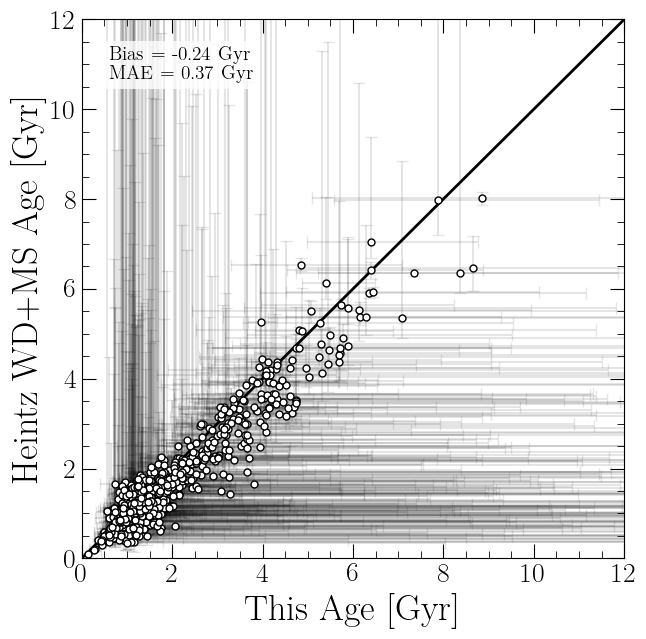

In [113]:
# residuals: y - x
res = y - x

bias = np.nanmean(res)
mae  = np.nanmean(np.abs(res))

plt.scatter(x, y, c = 'white', edgecolor = 'k', zorder = 1, label="Primary WD")
plt.errorbar(x, y, xerr=[xlo, xhi], yerr=[ylo, yhi], fmt='None', 
             c = 'k', alpha=0.1, capsize=4, zorder = 0)

#plt.scatter(x_sec, y_sec, c = 'white', edgecolor = 'k', zorder = 1, label="Secondary WD", marker = 'v')
#plt.errorbar(x_sec, y_sec, xerr=[xlo_sec, xhi_sec], yerr=[ylo_sec, yhi_sec], fmt='None', 
#             c = 'k', alpha=0.5, capsize=4, zorder = 0)

plt.plot([-1, 20], [-1, 20], c='k', lw=2, zorder=0)
plt.xlim(0, 12) ; plt.ylim(0, 12)

plt.xlabel("This Age [Gyr]") ; plt.ylabel("Heintz WD+MS Age [Gyr]") 
#plt.legend(framealpha=0, loc='lower right')

plt.text(
    0.05, 0.95,
    fr"Bias = {bias:.2f} Gyr" "\n" fr"MAE = {mae:.2f} Gyr",
    transform=plt.gca().transAxes,
    va="top",
    ha="left",
    fontsize=14,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.8)
)

print(res.shape)
plt.savefig("figures/heintz_agreement.pdf")

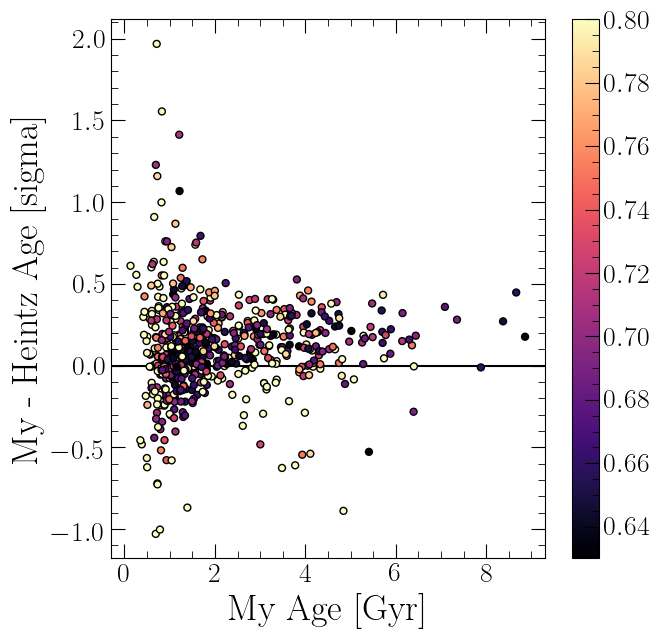

In [114]:
sigma_eff_x = (xhi + xlo)*0.5
sigma_eff_y = (yhi + ylo)*0.5

plt.scatter(x, (x-y) / np.sqrt(sigma_eff_x**2 + sigma_eff_y**2), c = c, edgecolor = 'k', zorder = 1, label="Primary WD", vmax=0.8)
plt.axhline(0, c="k", zorder=0)
plt.xlabel("My Age [Gyr]") ; plt.ylabel("My - Heintz Age [sigma]") 
plt.colorbar()


In [ ]:
data["wd_age"] = 10**(data["log_age"] - 9)
data["wd_age_lo"] = 10**(data["log_age_lo"] - 9)
data["wd_age_hi"] = 10**(data["log_age_hi"] - 9)

data["wd_cool_age"] = 10**(data["log_age_cool"] - 9)
data["wd_cool_age_lo"] = 10**(data["log_age_cool_lo"] - 9)
data["wd_cool_age_hi"] = 10**(data["log_age_cool_hi"] - 9)

5843


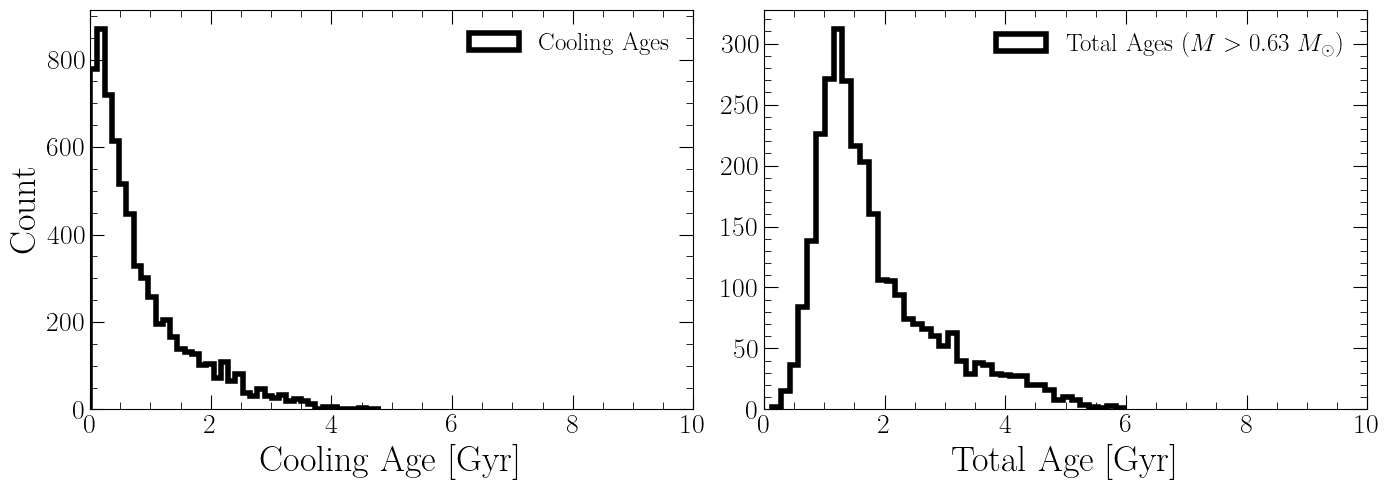

In [ ]:
mask = data["mass_best"] > 0.45

print(mask.sum())

fig, ax = plt.subplots(ncols=2, figsize=(14, 5))
ax[0].hist(data.loc[:,"wd_cool_age"], histtype="step", color="k", linewidth=4, label="Cooling Ages", bins=40);
ax[0].set_xlabel("Cooling Age [Gyr]") ; ax[0].set_ylabel("Count")
ax[0].set_xlim(0, 10)
ax[0].legend(framealpha=0)

ax[1].hist(data.loc[:,"wd_age"], histtype="step", color="k", linewidth=4, label=r"Total Ages ($M > 0.63~M_\odot$)", bins=40);
ax[1].set_xlabel("Total Age [Gyr]")
ax[1].set_xlim(0, 10)
ax[1].legend(framealpha=0)

fig.tight_layout()
fig.savefig("figures/age_dist.pdf")

In [ ]:
import os, sys, glob, re
coolingdir = os.environ['COOLING_PATH']

data_mist = pd.read_parquet(os.path.join(coolingdir, "summary.pqt")).query("fe_h == 0")

Text(0, 0.5, 'Mass')

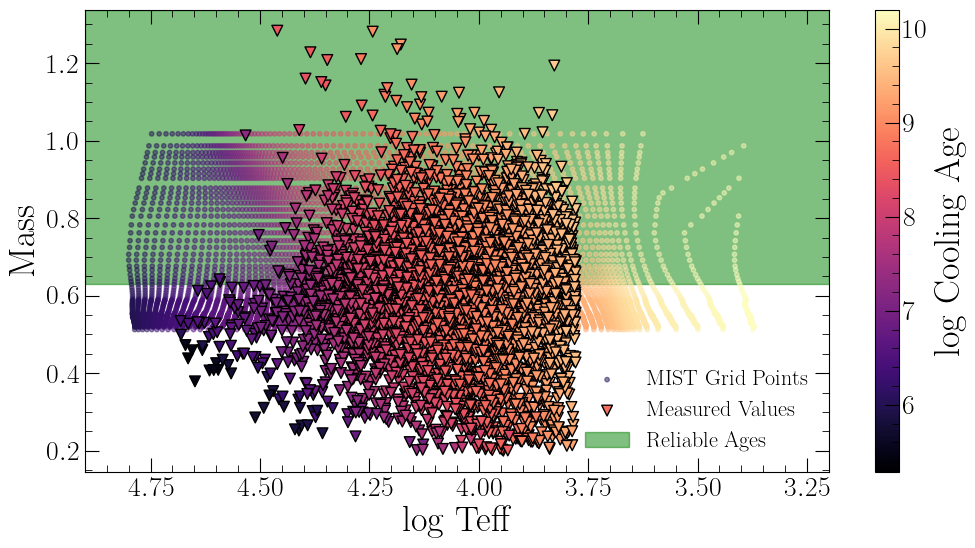

In [ ]:
gleegle = data.loc[:]

vmin = min(data_mist.log_age.min(), gleegle["log_age_cool"].min())
vmax = max(data_mist.log_age.max(), gleegle["log_age_cool"].max())

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(np.log10(data_mist.teff), data_mist.Mass, c=data_mist.log_age, 
           s=10, alpha=0.5, label="MIST Grid Points", vmin=vmin, vmax=vmax)
ax.scatter(np.log10(gleegle["teff_best"]), gleegle["mass_best"], s=60, 
           c=gleegle["log_age_cool"], marker="v", edgecolor="k", 
           label="Measured Values", vmin=vmin, vmax=vmax)

ax.invert_xaxis()

sm = plt.cm.ScalarMappable(norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='log Cooling Age')  # <-- pass ax=ax

ymin, ymax = ax.get_ylim()
ax.axhspan(0.63, ymax, alpha=0.5, color='green', label='Reliable Ages', zorder=0)
ax.set_ylim(ymin, ymax)
ax.set_xlim(4.9, 3.2)
ax.legend(framealpha=0, fontsize=16)
ax.set_xlabel("log Teff")
ax.set_ylabel("Mass")

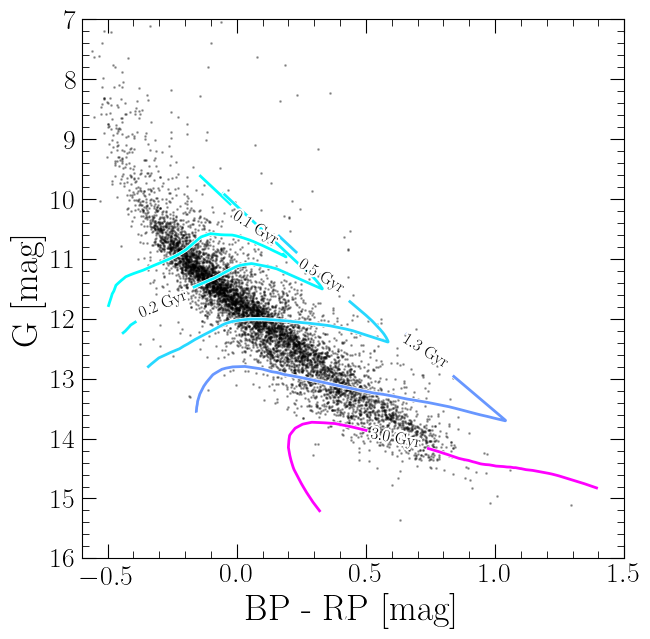

In [ ]:
from matplotlib import colors, cm
from matplotlib.ticker import LogFormatter
from matplotlib import patheffects

HR_grid = (-0.6, 1.4, 0.002, 9, 16, 0.01)
model  = WD_models.load_model(
    'be', 'be', 'be', 'H', 
    HR_bands=('bp3-rp3', 'G3'),
    HR_grid=HR_grid, 
    interp_type_atm='linear',
) 

fig, ax = plt.subplots()
ax.scatter(data["BP-RP"], data["GmagCorr"] - 5*np.log10(data["rgeo"]) + 5, s=1, c="k", alpha=0.3, zorder=2, rasterized=True)
ax.invert_yaxis()

levels = np.geomspace(0.1, 3, num=5)

contour2 = ax.contour(
    model['grid_HR_to_age_cool'].T,
    levels=levels,
    extent=(HR_grid[0], HR_grid[1], HR_grid[3], HR_grid[4]),
    cmap="cool",
    linewidths=2,
    zorder=3
)
contour2.set(path_effects=[patheffects.withStroke(linewidth=3, foreground="w")])

clbls = ax.clabel(contour2, inline=True, fontsize=12,
          fmt=lambda x: f"{x:1.1f} Gyr",
          colors='k')        # force black text
plt.setp(clbls, path_effects=[
    patheffects.withStroke(linewidth=3, foreground="w")])

ax.set_xlim(-0.6, 1.5)
ax.set_ylim(16, 7)

ax.set_xlabel(r"BP - RP [mag]")
ax.set_ylabel(r"G [mag]")

fig.savefig("figures/cmd.pdf")

In [ ]:
data_reset = pd.read_parquet("../widebinaries/data/merges/ngf21_merged.pqt").query("teff_best > 6000")
data_reset["wd_age"] = 10**(data_reset["log_age"] - 9)
data_reset["wd_age_lo"] = 10**(data_reset["log_age_lo"] - 9)
data_reset["wd_age_hi"] = 10**(data_reset["log_age_hi"] - 9)

data_reset["wd_cool_age"] = 10**(data_reset["log_age_cool"] - 9)
data_reset["wd_cool_age_lo"] = 10**(data_reset["log_age_cool_lo"] - 9)
data_reset["wd_cool_age_hi"] = 10**(data_reset["log_age_cool_hi"] - 9)

stellarhosts = pd.read_csv("../widebinaries/data/stellarhosts.csv", comment="#")
print(len(stellarhosts))
stellarhosts = pd.merge(data_reset, stellarhosts, left_on="sourceid", right_on="wd_source_id")
print(len(stellarhosts))
stellarhosts.loc[:, "reliable_age"] = stellarhosts.mass_best > 0.63
print(len(stellarhosts))

mask = ~stellarhosts.reliable_age
stellarhosts.loc[mask, "wd_age"] = np.nan 
stellarhosts.loc[mask, "wd_age_hi"] = np.nan 
stellarhosts.loc[mask, "wd_age_lo"] = np.nan 

11
6
6


In [ ]:
stellarhosts[["wd_source_id", "ms_source_id","sy_pnum", "wd_cool_age", "wd_cool_age_hi", "wd_cool_age_lo", "wd_age", "wd_age_hi", "wd_age_lo"]].to_latex("exoplanets.tex")

In [ ]:
def latex_ci(med, hi, lo, fmt="{:.2f}"):
    plus = hi - med
    minus = med - lo
    if np.isnan(med):
        return "-"
    else:
        return rf"${fmt.format(med)}^{{+{fmt.format(plus)}}}_{{-{fmt.format(minus)}}}$"

df = stellarhosts.copy()

df["wd_cool_age_tex"] = [
    latex_ci(m, h, l)
    for m, h, l in zip(df.wd_cool_age, df.wd_cool_age_hi, df.wd_cool_age_lo)
]

df["wd_age_tex"] = [
    latex_ci(m, h, l)
    for m, h, l in zip(df.wd_age, df.wd_age_hi, df.wd_age_lo)
]

In [ ]:
df[["wd_source_id", "ms_source_id","sy_pnum","wd_cool_age_tex", "wd_age_tex"]].to_latex(
    "exoplanets.tex",
    escape=False,   # critical so LaTeX math is not escaped
    index=False
)

In [ ]:
df[["wd_source_id", "ms_source_id","sy_pnum","radius_best","teff_best","mass_best","wd_cool_age", "wd_age"]]

,wd_source_id,ms_source_id,sy_pnum,radius_best,teff_best,mass_best,wd_cool_age,wd_age
0,6160221736672454400,6160221740968692992,1,0.010870,7274.172972,0.740642,1.981429,2.418752
1,4984244267802428032,4984244302162168704,1,0.014414,7277.384132,0.479038,2.275432,NaN
2,2645940445519931520,2645940376800212096,1,0.013381,7601.284332,0.550272,1.258925,NaN
3,6009537829925128064,6009538585839374336,2,0.012354,10648.860741,0.637055,0.565886,1.711442
4,3693358792919145600,3693358861640279296,2,0.011543,6401.810262,0.680094,2.390221,3.086508
5,6018034958869558912,6018047019138644480,1,0.012420,25901.220467,0.686405,0.020650,0.658792
